## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.common import config
from src.common import data_loader, preprocessor, feature_engineering, labeling
from src.common import walk_forward, backtester, metrics, visualization
from src.strategies.ml_strategy import quantile_positions
from src.models.bayesian_glm.model import BayesianGLMModel
from src.common.tuning import TunedModel
from src.models.bayesian_glm.config import PARAM_GRID

np.random.seed(config.RANDOM_SEED)

MARKET = "Nikkei225"
MODEL_NAME = "bayesian_glm"
print(f"Market: {MARKET} | Period: {config.START_DATE} -> {config.END_DATE}")
print(f"Inner-tuning grid: {PARAM_GRID}")

Market: Nikkei225 | Period: 2006-05-16 -> 2026-05-11
Inner-tuning grid: {'prior_sigma': [0.005]}


## 2. Data

In [3]:
raw = preprocessor.clean(data_loader.download_index(MARKET))
X = feature_engineering.build_paper_feature_matrix(raw)
y = labeling.next_day_return(raw, horizon=1)
common = X.index.intersection(y.index)
X = X.loc[common]
y = y.loc[common]
fwd_ret = y.copy()  # for the backtester / hit-rate
print(f"Features ({len(X.columns)}): {list(X.columns)}")
print(f"Observations: {len(X)}  ({X.index.min().date()} -> {X.index.max().date()})")
print(f"Target (next-day return) std: {y.std():.4f}")

Features (7): ['sma_signal_15', 'macd_hist', 'stoch_k_14', 'stoch_d_3', 'stoch_slow_d_3', 'rsi_14', 'willr_14']
Observations: 4867  (2006-06-08 -> 2026-05-01)
Target (next-day return) std: 0.0148


## 3. Walk-forward Validation

In [4]:
trimmed_index = walk_forward.trim_to_full_folds(
    X.index, train_window=config.TRAIN_WINDOW, step=config.STEP,
)
X_wf, y_wf, fwd_wf = X.loc[trimmed_index], y.loc[trimmed_index], fwd_ret.loc[trimmed_index]
total_folds = (len(trimmed_index) - config.TRAIN_WINDOW) // config.STEP
print(f"Trimmed {len(X) - len(trimmed_index)} leading rows | {total_folds} folds of {config.TRAIN_WINDOW}/{config.TEST_WINDOW}d")
print(f"Inner-tuning grid: {PARAM_GRID}")

from itertools import product
_grid_keys = list(PARAM_GRID.keys())
_grid_points = [dict(zip(_grid_keys, vals)) for vals in product(*(PARAM_GRID[k] for k in _grid_keys))]
_single_grid_point = len(_grid_points) == 1
if _single_grid_point:
    print("Single grid point: fitting the selected setting directly (no redundant inner hold-out).")
else:
    print(f"Validation hold-out size: 20 days  |  inner-train size: {config.TRAIN_WINDOW - 20} days")

oos_score = []
best_params_log: list[dict] = []
for fold, (train_idx, test_idx) in enumerate(
    walk_forward.rolling_splits(
        index=X_wf.index,
        train_window=config.TRAIN_WINDOW,
        test_window=config.TEST_WINDOW,
        step=config.STEP,
    )
):
    if _single_grid_point:
        params = {**_grid_points[0], **{"n_advi": 5000, "n_posterior": 500}}
        model = BayesianGLMModel(params=params)
        model.fit(X_wf.loc[train_idx], y_wf.loc[train_idx])
        best_params = _grid_points[0]
        val_score = np.nan
    else:
        model = TunedModel(
            BayesianGLMModel,
            param_grid=PARAM_GRID,
            val_size=20,
            scoring="neg_mse",
        inner_cv_overrides={"n_advi": 5000},
        final_overrides={"n_advi": 5000, "n_posterior": 500},
        )
        model.fit(X_wf.loc[train_idx], y_wf.loc[train_idx])
        best_params = model.best_params_
        val_score = model.best_score_
    best_params_log.append({"fold": fold, **best_params, "val_score": val_score})
    oos_score.append(model.predict_score(X_wf.loc[test_idx]))
    if fold % 20 == 0 or fold == total_folds - 1:
        if pd.notna(val_score):
            print(f"  fold {fold:>3d}/{total_folds-1}: best={best_params} (val score {val_score:+.6f})")
        else:
            print(f"  fold {fold:>3d}/{total_folds-1}: fixed={best_params}")

oos_score = pd.concat(oos_score).sort_index()
print(f"\nTotal out-of-sample observations: {len(oos_score)}")

best_params_df = pd.DataFrame(best_params_log)
print("\nBest-param frequency across folds:")
print(best_params_df.drop(columns=["fold", "val_score"]).value_counts().head(10))

Trimmed 7 leading rows | 233 folds of 200/20d
Inner-tuning grid: {'prior_sigma': [0.005]}
Single grid point: fitting the selected setting directly (no redundant inner hold-out).


C:\Users\Henrik\AppData\Roaming\Python\Python312\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Finished [100%]: Average Loss = 75,983


  fold   0/232: fixed={'prior_sigma': 0.005}


Finished [100%]: Average Loss = 81,386
Finished [100%]: Average Loss = 79,635
Finished [100%]: Average Loss = 77,406
Finished [100%]: Average Loss = 76,961
Finished [100%]: Average Loss = 74,741
Finished [100%]: Average Loss = 70,799
Finished [100%]: Average Loss = 66,393
Finished [100%]: Average Loss = 66,568
Finished [100%]: Average Loss = 66,188
Finished [100%]: Average Loss = 67,478
Finished [100%]: Average Loss = 67,585
Finished [100%]: Average Loss = 68,164
Finished [100%]: Average Loss = 70,305
Finished [100%]: Average Loss = 70,656
Finished [100%]: Average Loss = 70,087
Finished [100%]: Average Loss = 71,866
Finished [100%]: Average Loss = 67,795
Finished [100%]: Average Loss = 65,900
Finished [100%]: Average Loss = 65,700
Finished [100%]: Average Loss = 62,825


  fold  20/232: fixed={'prior_sigma': 0.005}


...

  fold 200/232: fixed={'prior_sigma': 0.005}


Finished [100%]: Average Loss = 68,588
Finished [100%]: Average Loss = 70,214
Finished [100%]: Average Loss = 69,065
Finished [100%]: Average Loss = 67,502
Finished [100%]: Average Loss = 65,718
Finished [100%]: Average Loss = 67,431
Finished [100%]: Average Loss = 68,638
Finished [100%]: Average Loss = 63,933
Finished [100%]: Average Loss = 63,806
Finished [100%]: Average Loss = 63,600
Finished [100%]: Average Loss = 66,120
Finished [100%]: Average Loss = 75,945
Finished [100%]: Average Loss = 74,770
Finished [100%]: Average Loss = 70,099
Finished [100%]: Average Loss = 68,153
Finished [100%]: Average Loss = 64,431
Finished [100%]: Average Loss = 60,278
Finished [100%]: Average Loss = 59,411
Finished [100%]: Average Loss = 58,766
Finished [100%]: Average Loss = 59,582


  fold 220/232: fixed={'prior_sigma': 0.005}


Finished [100%]: Average Loss = 59,623
Finished [100%]: Average Loss = 61,670
Finished [100%]: Average Loss = 58,548
Finished [100%]: Average Loss = 57,894
Finished [100%]: Average Loss = 59,960
Finished [100%]: Average Loss = 64,575
Finished [100%]: Average Loss = 68,165
Finished [100%]: Average Loss = 67,583
Finished [100%]: Average Loss = 69,387
Finished [100%]: Average Loss = 68,191
Finished [100%]: Average Loss = 61,561
Finished [100%]: Average Loss = 66,216


  fold 232/232: fixed={'prior_sigma': 0.005}

Total out-of-sample observations: 4660

Best-param frequency across folds:
prior_sigma
0.005          233
Name: count, dtype: int64


## 4. Strategy & 5. Backtest

In [7]:
positions = quantile_positions(oos_score, q_low=0.5, q_high=0.5, mode='long_only')
fwd_oos = fwd_wf.loc[positions.index]

ml_bt = backtester.backtest(positions, fwd_oos)
bh_bt = backtester.buy_and_hold_backtest(fwd_oos)
print(f"Signal balance: +1={int((positions==1).sum())}  0={int((positions==0).sum())}  -1={int((positions==-1).sum())}")
ml_bt.tail()

Signal balance: +1=2330  0=2330  -1=0


,position,gross_return,equity
date,,,
2026-04-24,1.0,0.013751,2.627721
2026-04-27,1.0,-0.010240,2.600813
2026-04-28,1.0,-0.010557,2.573357
2026-04-30,1.0,0.003849,2.583262
2026-05-01,0.0,0.000000,2.583262


## 6. Metrics

In [9]:
summary = pd.DataFrame({
    f"{MODEL_NAME}": metrics.summary(
        ml_bt["gross_return"], ml_bt["equity"], positions, fwd_oos,
    ),
    "buy_and_hold": metrics.summary(
        bh_bt["gross_return"], bh_bt["equity"],
        pd.Series(1.0, index=fwd_oos.index), fwd_oos,
    ),
}).T

summary.to_csv(config.TABLES_DIR / f"{MARKET}_{MODEL_NAME}.csv")
summary.style.format("{:.4f}")

,CAGR,ARC,ASD,Sharpe,aSharpe,IR,IR_star,MDD,Calmar,Sortino,HitRate
bayesian_glm,0.0526,0.0527,0.1537,0.4109,0.3425,0.3426,0.0537,0.3355,0.1569,0.5191,0.5313
buy_and_hold,0.0710,0.0710,0.2375,0.4081,0.2990,0.2991,0.0346,0.6137,0.1157,0.4753,0.5275


## 7. Plots

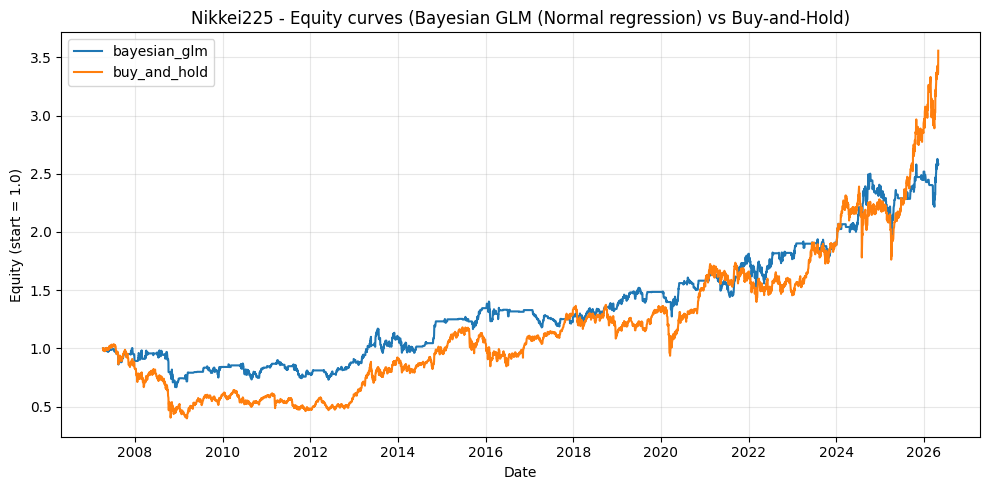

In [10]:
fig_eq = visualization.plot_equity_curve(
    {f"{MODEL_NAME}": ml_bt["equity"], "buy_and_hold": bh_bt["equity"]},
    title=f"{MARKET} - Equity curves (Bayesian GLM (Normal regression) vs Buy-and-Hold)",
)
fig_eq.savefig(config.FIGURES_DIR / f"{MARKET}_{MODEL_NAME}_equity.png", dpi=150)
plt.show()

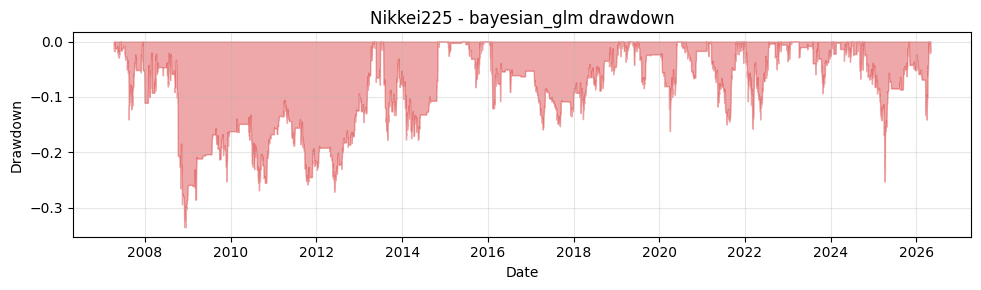

In [11]:
fig_dd = visualization.plot_drawdown(ml_bt["equity"], title=f"{MARKET} - {MODEL_NAME} drawdown")
fig_dd.savefig(config.FIGURES_DIR / f"{MARKET}_{MODEL_NAME}_drawdown.png", dpi=150)
plt.show()